In [2]:
import numpy as np
import scipy.sparse as sparse
import scipy.linalg as linalg
import QO_trunc_functions as QOtrunc
import importlib
import matplotlib.pyplot as plt
import time
import copy

In [3]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [4]:
'''
# this cell creates the raw data to plot, it is commented because it takes a long time to evaluate
importlib.reload(QOtrunc)
int_data={}
(int_data['loss_diff_arr_coh'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[0,0],[0,0]],phis_squeeze=[[0,0],[0,0]],start_photons=[0,0],n_points=10,n_sub=31,add_func=None)
(int_data['loss_diff_arr_squeeze'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[1,1],[1,1]],phis_squeeze=[[0,0],[0,0]],start_photons=[0,0],n_points=10,n_sub=31,add_func=None)
(int_data['loss_diff_arr_ep'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[0,0],[0,0]],phis_squeeze=[[0,0],[0,0]],start_photons=[1,0],n_points=10,n_sub=31,add_func=None)
(int_data['loss_diff_arr_epBoth'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[0,0],[0,0]],phis_squeeze=[[0,0],[0,0]],start_photons=[1,1],n_points=10,n_sub=31,add_func=None)
(int_data['loss_diff_arr_epSqueeze'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[1,1],[1,1]],phis_squeeze=[[0,0],[0,0]],start_photons=[1,0],n_points=10,n_sub=31,add_func=None)
(int_data['loss_diff_arr_epSqueezeBoth'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[1,1],[1,1]],phis_squeeze=[[np.pi/2,0],[np.pi/2,0]],start_photons=[1,1],n_points=10,n_sub=31,add_func=None)
gadg_params={'phi_int': np.pi}
(int_data['loss_diff_arr_coh_f'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[0,0],[0,0]],phis_squeeze=[[0,0],[0,0]],start_photons=[0,0],n_points=10,n_sub=31,add_func=None,gadg_params=gadg_params)
(int_data['loss_diff_arr_squeeze_f'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[1,1],[1,1]],phis_squeeze=[[0,0],[0,0]],start_photons=[0,0],n_points=10,n_sub=31,add_func=None,gadg_params=gadg_params)
(int_data['loss_diff_arr_ep_f'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[0,0],[0,0]],phis_squeeze=[[0,0],[0,0]],start_photons=[1,0],n_points=10,n_sub=31,add_func=None,gadg_params=gadg_params)
(int_data['loss_diff_arr_epBoth_f'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[0,0],[0,0]],phis_squeeze=[[0,0],[0,0]],start_photons=[1,1],n_points=10,n_sub=31,add_func=None,gadg_params=gadg_params)
(int_data['loss_diff_arr_epSqueeze_f'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[1,1],[1,1]],phis_squeeze=[[0,0],[0,0]],start_photons=[1,0],n_points=10,n_sub=31,add_func=None,gadg_params=gadg_params)
(int_data['loss_diff_arr_epSqueezeBoth_f'],data_dict_int,data_dict_noInt)=QOtrunc.photon_loss_rates_int_gadget([[1,0],[0,1]],[[1,1],[1,1]],phis_squeeze=[[np.pi/2,0],[np.pi/2,0]],start_photons=[1,1],n_points=10,n_sub=31,add_func=None,gadg_params=gadg_params)
int_data['frac1_arr']=np.linspace(0,1,10)
np.save('interaction_data.npy',int_data)
'''

In [5]:
int_data=np.load('interaction_data.npy',allow_pickle=True)[()]

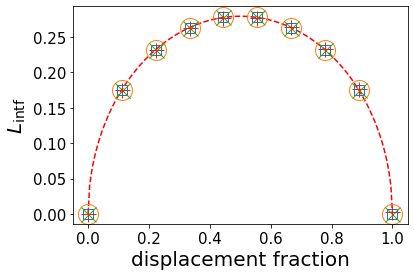

In [6]:

plt.plot(np.linspace(0,1,200),4*np.sin(np.pi/5)*np.cos(np.pi/5)*np.sin(np.pi/10)*np.cos(np.pi/10)*np.sqrt(np.linspace(0,1,200))*np.sqrt(1-np.linspace(0,1,200)),'--r')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_coh'],'s',markersize=10,mfc='none')
#plt.plot(frac1_arr,loss_diff_arr_squeeze,'*',markersize=15,mfc='none')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_ep'],'o',markersize=20,mfc='none')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_epBoth'],'x',markersize=15,mfc='none')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_epSqueezeBoth'],'+',markersize=15,mfc='none')
plt.ylabel(r'$L_\mathrm{intf}$',fontsize=20)
plt.xlabel('displacement fraction',fontsize=20)
ax1=plt.gca()
ax1.tick_params(labelsize=15)
#plt.savefig('figures/interference_loss_af.pdf',bbox_inches='tight')

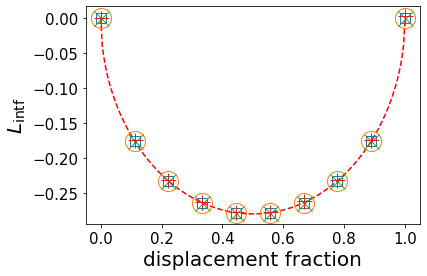

In [7]:

plt.plot(np.linspace(0,1,200),-4*np.sin(np.pi/5)*np.cos(np.pi/5)*np.sin(np.pi/10)*np.cos(np.pi/10)*np.sqrt(np.linspace(0,1,200))*np.sqrt(1-np.linspace(0,1,200)),'--r')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_coh_f'],'s',markersize=10,mfc='none')
#plt.plot(frac1_arr,loss_diff_arr_squeeze,'*',markersize=15,mfc='none')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_ep_f'],'o',markersize=20,mfc='none')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_epBoth_f'],'x',markersize=15,mfc='none')
plt.plot(int_data['frac1_arr'],int_data['loss_diff_arr_epSqueezeBoth_f'],'+',markersize=15,mfc='none')
plt.ylabel(r'$L_\mathrm{intf}$',fontsize=20)
plt.xlabel('displacement fraction',fontsize=20)
ax1=plt.gca()
ax1.tick_params(labelsize=15)
#plt.savefig('figures/interference_loss_f.pdf',bbox_inches='tight')

In [ ]:
'''
# this cell creates the raw data to plot, it is commented because it takes a long time to evaluate
importlib.reload(QOtrunc)
cat_data={}
n_sub=1001
n_div=200
cat_data['squeeze_photon_nums']=np.linspace(30/n_div,30,n_div)

n_loss_list=list(range(0,11))
cat_data['cat_fid_arr']=np.zeros([n_div,len(n_loss_list)])
cat_data['vac_fid_arr']=np.zeros([n_div,len(n_loss_list)])
cat_data['unsq_cat_fid_arr']=np.zeros([n_div,len(n_loss_list)])
cat_data['final_count_arr']=np.zeros([n_div,len(n_loss_list)])
cat_data['squeeze_frac_arr']=np.zeros([n_div,len(n_loss_list)])
cat_data['p_num_arr']=np.zeros([n_div,len(n_loss_list)])
for i_squeeze in range(len(cat_data['squeeze_photon_nums'])):
    (psi_sub_renorm_list_1,p_list_1)=QOtrunc.squeeze_beam_split_analytic_range(11,n_hat_squeeze=cat_data['squeeze_photon_nums'][i_squeeze],theta=0,theta_subtract=np.pi/5,n_sub=n_sub)
    for i_loss in range(len(n_loss_list)):
        n_loss=n_loss_list[i_loss]
        final_count=QOtrunc.mean_photon_count_subspace(psi_sub_renorm_list_1[n_loss],n_sub)
        cat_data['final_count_arr'][i_squeeze,i_loss]=copy.copy(final_count)
        psi_cat=QOtrunc.prepare_cat_state_photon_number(n_hat_disp=final_count,n_sub=n_sub,phi_disp=np.pi/2,phi_sup=np.pi*n_loss)
        cat_data['unsq_cat_fid_arr'][i_squeeze,i_loss]=abs(psi_cat@psi_sub_renorm_list_1[n_loss])**2
        (abs_fid_best,squeeze_frac_best,n_hat_total)=QOtrunc.squeeze_cat_fid(psi_sub_renorm_list_1[n_loss],phi_sup=np.pi*n_loss,phi_disp=np.pi/2,phi_squeeze=0)
        cat_data['squeeze_frac_arr'][i_squeeze,i_loss]=squeeze_frac_best
        cat_data['cat_fid_arr'][i_squeeze,i_loss]=abs_fid_best
        cat_data['vac_fid_arr'][i_squeeze,i_loss]=abs(psi_sub_renorm_list_1[n_loss][0])**2
        cat_data['p_num_arr'][i_squeeze,i_loss]=p_list_1[n_loss]
np.save('cat_compare_data.npy',cat_data)
'''

In [9]:
cat_data=np.load('cat_compare_data.npy',allow_pickle=True)[()]

In [10]:
n_sub=101
n_loss_list=list(range(0,11))
final_count_arr_infty=np.zeros(11)
cat_fid_arr_infty=np.zeros(11)
vac_fid_arr_infty=np.zeros(11)
squeeze_frac_arr_infty=np.zeros(11)
n_hat_total_arr_infty=np.zeros(11)
match_squeezing_arr_odd=np.zeros([5,5])
(psi_sub_renorm_list_1,psi_sub_renorm_list_infty,p_list_1)=QOtrunc.prepare_two_mode_photon_subtract_states(n_hat_squeeze=np.infty,theta_subtract=np.pi/5,displacement_photons_add=3,squeezing_photons_add=0,squeeezing_photon_angle=0,n_sub=n_sub,return_kit=True)
for i_loss in range(len(n_loss_list)):
    n_loss=n_loss_list[i_loss]
    final_count_arr_infty[i_loss]=QOtrunc.mean_photon_count_subspace(psi_sub_renorm_list_infty[n_loss],n_sub)
    (cat_fid_arr_infty[i_loss],squeeze_frac_arr_infty[i_loss],n_hat_total_arr_infty[i_loss])=QOtrunc.squeeze_cat_fid(psi_sub_renorm_list_infty[n_loss],phi_sup=np.pi*n_loss,phi_disp=np.pi/2,phi_squeeze=0)
    vac_fid_arr_infty[i_loss]=abs(psi_sub_renorm_list_1[n_loss][0])**2
    n_disp=(1-squeeze_frac_arr_infty[i_loss])*n_hat_total_arr_infty[i_loss]
        

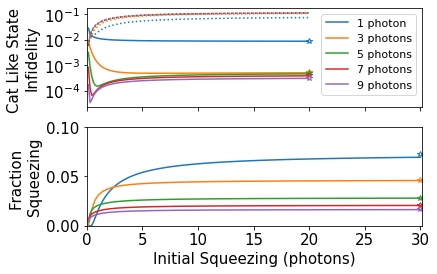

In [11]:
fig,(ax0,ax1)=plt.subplots(2,1,sharex='col')
i_color=0
for photon_number in [1,3,5,7,9]:
    if photon_number==1:
        ax0.semilogy(cat_data['squeeze_photon_nums'][cat_data['squeeze_photon_nums']<20],1-cat_data['cat_fid_arr'][cat_data['squeeze_photon_nums']<20,photon_number],label='1 photon')
    else:
        ax0.semilogy(cat_data['squeeze_photon_nums'][cat_data['squeeze_photon_nums']<20],1-cat_data['cat_fid_arr'][cat_data['squeeze_photon_nums']<20,photon_number],label=str(photon_number)+' photons')
    ax0.semilogy(cat_data['squeeze_photon_nums'][cat_data['squeeze_photon_nums']<20],1-cat_data['unsq_cat_fid_arr'][cat_data['squeeze_photon_nums']<20,photon_number],':',color=colors[i_color])
    ax0.plot([20],[1-cat_fid_arr_infty[photon_number]],'*',color=colors[i_color],mfc='none')
    i_color=i_color+1
    ax0.legend(fontsize=11)
plt.sca(ax0)
ax0.tick_params(labelsize=15)
plt.ylabel('Cat Like State \nInfidelity',fontsize=15)
plt.yticks([10**-1,10**-2,10**-3,10**-4])
i_color=0
for photon_number in [1,3,5,7,9]:
    if photon_number==1:
        ax1.plot(cat_data['squeeze_photon_nums'],cat_data['squeeze_frac_arr'][:,photon_number],label='1 photon')
    else:
        ax1.plot(cat_data['squeeze_photon_nums'],cat_data['squeeze_frac_arr'][:,photon_number],label=str(photon_number)+' photons')
    ax1.plot([30],[squeeze_frac_arr_infty[photon_number]],'*',color=colors[i_color],mfc='none')
    i_color=i_color+1
plt.sca(ax1)
ax1.tick_params(labelsize=15)
plt.xlabel('Initial Squeezing (photons)',fontsize=15)
plt.ylabel('Fraction \nSqueezing',fontsize=15)
plt.xlim([0,30.1])
plt.ylim([0,0.1])
#plt.savefig('figures/kitten_infid_and_squeezing.pdf',bbox_inches='tight')
plt.show()


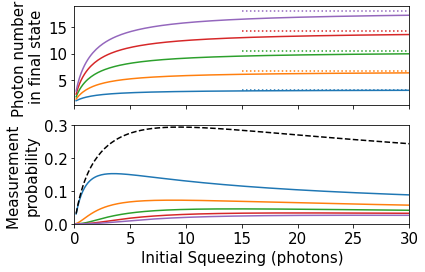

In [12]:
fig,(ax0,ax1)=plt.subplots(2,1,sharex='col')
i_color=0
for photon_number in [1,3,5,7,9]:
    if photon_number==1:
        ax0.plot(cat_data['squeeze_photon_nums'],cat_data['final_count_arr'][:,photon_number],label='1 photon')
    else:
        ax0.plot(cat_data['squeeze_photon_nums'],cat_data['final_count_arr'][:,photon_number],label=str(photon_number)+' photons')
    ax0.plot([15,30],[final_count_arr_infty[photon_number],final_count_arr_infty[photon_number]],':',color=colors[i_color])
    i_color=i_color+1
plt.sca(ax0)
ax0.tick_params(labelsize=15)
plt.ylabel('Photon number \nin final state',fontsize=15)


ax1.plot(cat_data['squeeze_photon_nums'],cat_data['p_num_arr'][:,[1,3,5,7,9]])
ax1.plot(cat_data['squeeze_photon_nums'],cat_data['p_num_arr'][:,[1,3,5,7,9]].sum(1),'--k')

plt.sca(ax1)
ax1.tick_params(labelsize=15)
plt.xlabel('Initial Squeezing (photons)',fontsize=15)
plt.ylabel('Measurement \nprobability',fontsize=15)
plt.xlim([0,30])
plt.ylim([0,0.3])
plt.yticks([0,0.1,0.2,0.3])
#plt.savefig('figures/kitten_prob_and_num.pdf',bbox_inches='tight')
plt.show()

In [13]:
n_sub=1001
n_loss_list=list(range(0,11))
final_count_arr_infty=np.zeros(11)
cat_fid_arr_infty=np.zeros(11)
vac_fid_arr_infty=np.zeros(11)
squeeze_frac_arr_infty=np.zeros(11)
n_hat_total_arr_infty=np.zeros(11)
match_squeezing_arr_odd=np.zeros([5,5])
squeeze_match_psi_list=np.zeros([5,5],dtype=object)
n_total_match_odd=np.zeros([5,5])
frac_non_disp_match_odd=np.zeros([5,5])
cat_fid_arr_match_odd=np.zeros([5,5])
squeeze_frac_arr_match_odd=np.zeros([5,5])
n_hat_total_arr_match_odd=np.zeros([5,5])
[psi_sub_renorm_list_infty,p_list_1]=QOtrunc.squeeze_beam_split_analytic_range(n_sub_detect=11,n_hat_squeeze=np.infty,theta=0,theta_subtract=np.pi/5,n_sub=n_sub)
for i_loss in range(len(n_loss_list)):
    n_loss=n_loss_list[i_loss]
    final_count_arr_infty[i_loss]=QOtrunc.mean_photon_count_subspace(psi_sub_renorm_list_infty[n_loss],n_sub)
    (cat_fid_arr_infty[i_loss],squeeze_frac_arr_infty[i_loss],n_hat_total_arr_infty[i_loss])=QOtrunc.squeeze_cat_fid(psi_sub_renorm_list_infty[n_loss],phi_sup=np.pi*n_loss,phi_disp=np.pi/2,phi_squeeze=0)
    vac_fid_arr_infty[i_loss]=abs(psi_sub_renorm_list_1[n_loss][0])**2
    n_disp=(1-squeeze_frac_arr_infty[i_loss])*n_hat_total_arr_infty[i_loss]
    if i_loss%2==1:
        for i_loss_comp in range(1,i_loss+2,2):
            ind_1=int((i_loss_comp-1)/2)
            ind_2=int((i_loss-1)/2)
            n_disp_comp=(1-squeeze_frac_arr_infty[i_loss_comp])*n_hat_total_arr_infty[i_loss_comp]
            match_squeezing_arr_odd[ind_1,ind_2]=QOtrunc.calculate_squeezing_displacement_diff(n_disp_comp,n_disp)
            match_squeezing_arr_odd[ind_2,ind_1]=-match_squeezing_arr_odd[ind_1,ind_2]
            squeeze_match_psi_list[ind_2][ind_1]=QOtrunc.apply_squeezing_Op(-match_squeezing_arr_odd[ind_1,ind_2],psi_sub_renorm_list_infty[i_loss])
            n_total_match_odd[ind_1,ind_2]=QOtrunc.mean_photon_count_subspace(squeeze_match_psi_list[ind_2][ind_1],n_sub)
            frac_non_disp_match_odd[ind_1,ind_2]=1-((1-squeeze_frac_arr_infty[i_loss_comp])*n_hat_total_arr_infty[i_loss_comp])/n_total_match_odd[ind_1,ind_2]
            (cat_fid_arr_match_odd[ind_1,ind_2],squeeze_frac_arr_match_odd[ind_1,ind_2],n_hat_total_arr_match_odd[ind_1,ind_2])=QOtrunc.squeeze_cat_fid(squeeze_match_psi_list[ind_2][ind_1],phi_sup=np.pi*n_loss,phi_disp=np.pi/2,phi_squeeze=np.pi)
            squeeze_match_psi_list[ind_1][ind_2]=QOtrunc.apply_squeezing_Op(match_squeezing_arr_odd[ind_1,ind_2],psi_sub_renorm_list_infty[i_loss_comp])
            n_total_match_odd[ind_2,ind_1]=QOtrunc.mean_photon_count_subspace(squeeze_match_psi_list[ind_1][ind_2],n_sub)
            frac_non_disp_match_odd[ind_2,ind_1]=1-((1-squeeze_frac_arr_infty[i_loss])*n_hat_total_arr_infty[i_loss])/n_total_match_odd[ind_2,ind_1]
            (cat_fid_arr_match_odd[ind_2,ind_1],squeeze_frac_arr_match_odd[ind_2,ind_1],n_hat_total_arr_match_odd[ind_2,ind_1])=QOtrunc.squeeze_cat_fid(squeeze_match_psi_list[ind_1][ind_2],phi_sup=np.pi*n_loss,phi_disp=np.pi/2,phi_squeeze=0)
            

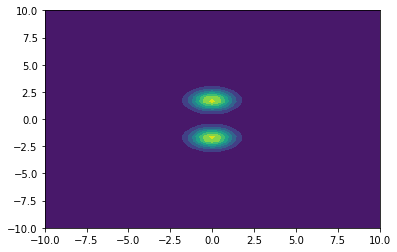

In [14]:
(re_alpha_array_9_1,im_alpha_array_9_1,Q_array_9_1)=QOtrunc.make_Q_plot_data_pure_state(squeeze_match_psi_list[4][0])
plt.contourf(im_alpha_array_9_1,re_alpha_array_9_1,Q_array_9_1.T)

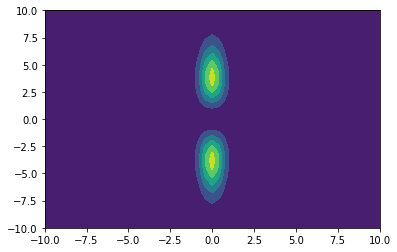

In [15]:
(re_alpha_array_1_9,im_alpha_array_1_9,Q_array_1_9)=QOtrunc.make_Q_plot_data_pure_state(squeeze_match_psi_list[0][4])
plt.contourf(im_alpha_array_1_9,re_alpha_array_1_9,Q_array_1_9.T)

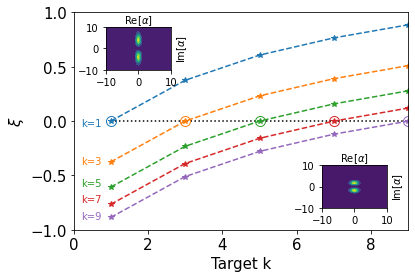

In [16]:
fig=plt.figure()
plt.plot([1,9],[0,0],':k')
plt.plot([1,3,5,7,9],match_squeezing_arr_odd.T,'--*')
plt.xlim([0,9])
plt.ylim([-1,1])
plt.text(0.2,-0.05,'k=1',color=colors[0])
plt.text(0.2,-0.4,'k=3',color=colors[1])
plt.text(0.2,-0.6,'k=5',color=colors[2])
plt.text(0.2,-0.75,'k=7',color=colors[3])
plt.text(0.2,-0.9,'k=9',color=colors[4])
plt.plot([1],[match_squeezing_arr_odd[0][0]],'o',mfc='none',markersize=10,color=colors[0])
plt.plot([3],[match_squeezing_arr_odd[1][1]],'o',mfc='none',markersize=10,color=colors[1])
plt.plot([5],[match_squeezing_arr_odd[2][2]],'o',mfc='none',markersize=10,color=colors[2])
plt.plot([7],[match_squeezing_arr_odd[3][3]],'o',mfc='none',markersize=10,color=colors[3])
plt.plot([9],[match_squeezing_arr_odd[4][4]],'o',mfc='none',markersize=10,color=colors[4])
ax0=plt.gca()
ax0.tick_params(labelsize=15)
plt.xlabel('Target k',fontsize=15)
plt.ylabel(r'$\xi$',fontsize=15)
fig.add_axes([0.7,0.2,0.15,0.15])
plt.contourf(im_alpha_array_9_1,re_alpha_array_9_1,Q_array_9_1.T)
ax1=plt.gca()
ax1.yaxis.set_label_position("right")
ax1.xaxis.set_label_position("top")
#ax1.yaxis.tick_right()
plt.xlabel(r'$\mathrm{Re}[\alpha]$',fontsize=10)
plt.ylabel(r'$\mathrm{Im}[\alpha]$',fontsize=10)
fig.add_axes([0.2,0.68,0.15,0.15])
ax2=plt.gca()
ax2.yaxis.set_label_position("right")
ax2.xaxis.set_label_position("top")
plt.contourf(im_alpha_array_1_9,re_alpha_array_1_9,Q_array_1_9.T)
plt.xlabel(r'$\mathrm{Re}[\alpha]$',fontsize=10)
plt.ylabel(r'$\mathrm{Im}[\alpha]$',fontsize=10)
#plt.savefig('figures/match_squeezing.pdf',bbox_inches='tight')
plt.show()

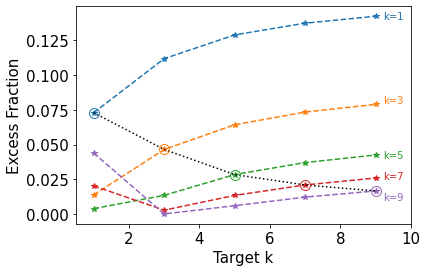

In [17]:
plt.plot([1,3,5,7,9],frac_non_disp_match_odd,'--*')
plt.plot([1,3,5,7,9],[frac_non_disp_match_odd[0][0],frac_non_disp_match_odd[1][1],frac_non_disp_match_odd[2][2],frac_non_disp_match_odd[3][3],frac_non_disp_match_odd[4][4]],':k')
plt.plot([1],[frac_non_disp_match_odd[0][0]],'o',mfc='none',markersize=10,color=colors[0])
plt.plot([3],[frac_non_disp_match_odd[1][1]],'o',mfc='none',markersize=10,color=colors[1])
plt.plot([5],[frac_non_disp_match_odd[2][2]],'o',mfc='none',markersize=10,color=colors[2])
plt.plot([7],[frac_non_disp_match_odd[3][3]],'o',mfc='none',markersize=10,color=colors[3])
plt.plot([9],[frac_non_disp_match_odd[4][4]],'o',mfc='none',markersize=10,color=colors[4])
plt.xlim([0.5,10])
plt.text(9.2,0.140,'k=1',color=colors[0])
plt.text(9.2,0.08,'k=3',color=colors[1])
plt.text(9.2,0.04,'k=5',color=colors[2])
plt.text(9.2,0.025,'k=7',color=colors[3])
plt.text(9.2,0.01,'k=9',color=colors[4])
ax0=plt.gca()
ax0.tick_params(labelsize=15)
plt.xlabel('Target k',fontsize=15)
plt.ylabel('Excess Fraction',fontsize=15)
#plt.savefig('figures/excess_photons_match.pdf',bbox_inches='tight')
plt.show()

In [18]:
'''
# this cell creates the raw data to plot, it is commented because it takes a long time to evaluate
theta_data={}
n_sub=1501
n_div=200
#squeeze_photon_nums=np.linspace(5/n_div,5,n_div)
theta_data['theta_subtract_vals']=np.linspace(np.pi/(20),np.pi/4,n_div)
#squeeze_photon_nums=np.logspace(0,4,n_div)
n_loss_list=list(range(0,11))
theta_data['cat_fid_arr_theta']=np.zeros([n_div,len(n_loss_list)])
theta_data['vac_fid_arr_theta']=np.zeros([n_div,len(n_loss_list)])
theta_data['final_count_arr_theta']=np.zeros([n_div,len(n_loss_list)])
theta_data['squeeze_frac_arr_theta']=np.zeros([n_div,len(n_loss_list)])
theta_data['p_num_arr_theta']=np.zeros([n_div,len(n_loss_list)])
theta_data['n_hat_total_fit_arr_theta']=np.zeros([n_div,len(n_loss_list)])
for i_theta in range(len(theta_data['theta_subtract_vals'])):
    [psi_sub_renorm_list_1,p_list_1]=QOtrunc.squeeze_beam_split_analytic_range(n_sub_detect=11,n_hat_squeeze=np.infty,theta=0,theta_subtract=theta_data['theta_subtract_vals'][i_theta],n_sub=n_sub)
    for i_loss in range(len(n_loss_list)):
        n_loss=n_loss_list[i_loss]
        final_count=QOtrunc.mean_photon_count_subspace(psi_sub_renorm_list_1[n_loss],n_sub)
        theta_data['final_count_arr_theta'][i_theta,i_loss]=copy.copy(final_count)
        (abs_fid_best,squeeze_frac_best,n_hat_total)=QOtrunc.squeeze_cat_fid(psi_sub_renorm_list_1[n_loss],phi_sup=np.pi*n_loss,phi_disp=np.pi/2,phi_squeeze=0)
        theta_data['n_hat_total_fit_arr_theta'][i_theta,i_loss]=n_hat_total
        theta_data['squeeze_frac_arr_theta'][i_theta,i_loss]=squeeze_frac_best
        theta_data['cat_fid_arr_theta'][i_theta,i_loss]=abs_fid_best
        theta_data['vac_fid_arr_theta'][i_theta,i_loss]=abs(psi_sub_renorm_list_1[n_loss][0])**2
        theta_data['p_num_arr_theta'][i_theta,i_loss]=p_list_1[n_loss]
np.save('vary_theta_data.npy',theta_data)
'''

In [19]:
theta_data=np.load('vary_theta_data.npy',allow_pickle=True)[()]

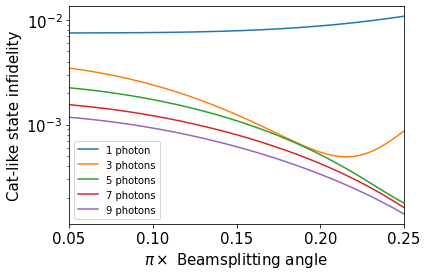

In [20]:
for photon_number in [1,3,5,7,9]:
    if photon_number==1:
        plt.semilogy(theta_data['theta_subtract_vals']/np.pi,1-theta_data['cat_fid_arr_theta'][:,photon_number],label='1 photon')
    else:
        plt.semilogy(theta_data['theta_subtract_vals']/np.pi,1-theta_data['cat_fid_arr_theta'][:,photon_number],label=str(photon_number)+' photons')
ax0=plt.gca()
ax0.tick_params(labelsize=15)
plt.xlim([1/(20),1/4])
plt.xlabel(r'$\pi \times$ Beamsplitting angle ',fontsize=15)
plt.ylabel('Cat-like state infidelity',fontsize=15)
plt.legend()
#plt.savefig('figures/fidelity_beamsplit_angle.pdf',bbox_inches='tight')
plt.show()

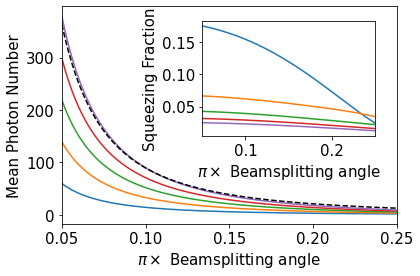

In [21]:
fig=plt.figure()
plt.plot(theta_data['theta_subtract_vals']/np.pi,theta_data['final_count_arr_theta'][:,[1,3,5,7,9]])
plt.plot(theta_data['theta_subtract_vals']/np.pi,-9/(2*np.log(np.cos(theta_data['theta_subtract_vals']))),'--k')
plt.xlim([1/(20),1/4])
ax0=plt.gca()
ax0.tick_params(labelsize=15)
plt.xlabel(r'$\pi \times$ Beamsplitting angle ',fontsize=15)
plt.ylabel('Mean Photon Number',fontsize=15)
fig.add_axes([0.45,0.43,0.40,0.40])
plt.plot(theta_data['theta_subtract_vals']/np.pi,theta_data['squeeze_frac_arr_theta'][:,[1,3,5,7,9]])
plt.xlim([1/(20),1/4])
ax1=plt.gca()
ax1.tick_params(labelsize=15)
plt.xlabel(r'$\pi \times$ Beamsplitting angle',fontsize=15)
plt.ylabel('Squeezing Fraction',fontsize=15)
#plt.savefig('figures/photon_number_beamsplit_angle.pdf',bbox_inches='tight')
plt.show()

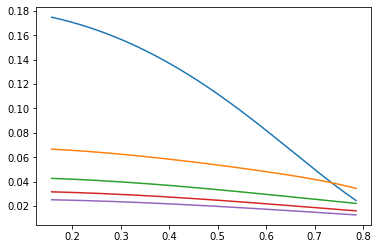

In [22]:
plt.plot(theta_data['theta_subtract_vals'],theta_data['squeeze_frac_arr_theta'][:,[1,3,5,7,9]])
plt.show()

In [23]:
n_sub=101
(psi_final_list,psi_sub_renorm_list,p_list)=QOtrunc.prepare_two_mode_photon_subtract_states(n_hat_squeeze=10,theta_subtract=np.pi/5,displacement_photons_add=4,squeezing_photons_add=0,squeeezing_photon_angle=0,n_sub=n_sub,return_kit=True)

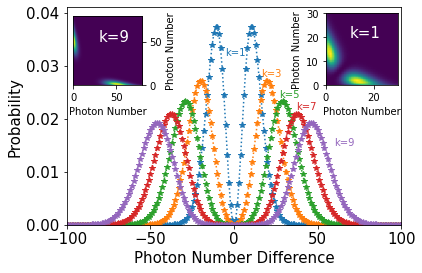

In [24]:
fig=plt.figure()
n_list=list(range(1,10,2))
for n_dect in n_list:
    psi_comb=psi_final_list[n_dect]
    (prob_arr,diff_arr,diff_probs)=QOtrunc.photon_number_diff_statistics(psi_comb)
    plt.plot(diff_arr,diff_probs,'*:')
plt.xlim([-100,100])
plt.ylim([0,0.041])
ax0=plt.gca()
ax0.tick_params(labelsize=15)
plt.text(-5,0.032,'k=1',color=colors[0])
plt.text(16,0.028,'k=3',color=colors[1])
plt.text(27,0.024,'k=5',color=colors[2])
plt.text(37,0.0217,'k=7',color=colors[3])
plt.text(60,0.015,'k=9',color=colors[4])
plt.xlabel('Photon Number Difference',fontsize=15)
plt.ylabel('Probability',fontsize=15)
fig.add_axes([0.683,0.61,0.25,0.25])
psi_comb=psi_final_list[1]
(prob_arr,diff_arr,diff_probs)=QOtrunc.photon_number_diff_statistics(psi_comb)
plt.imshow(prob_arr,interpolation=None)
plt.xlim([0,30])
plt.ylim([0,30])
plt.text(10,20,'k=1',color='w',fontsize=15)
plt.xlabel('Photon Number',fontsize=10)
plt.ylabel('Photon Number',fontsize=10)
fig.add_axes([0.095,0.61,0.25,0.24])
psi_comb=psi_final_list[9]
(prob_arr,diff_arr,diff_probs)=QOtrunc.photon_number_diff_statistics(psi_comb)
plt.imshow(prob_arr,interpolation=None)
plt.xlim([0,80])
plt.ylim([0,80])
plt.text(30,50,'k=9',color='w',fontsize=15)
ax2=plt.gca()
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
plt.xlabel('Photon Number',fontsize=10)
plt.ylabel('Photon Number',fontsize=10)
#plt.savefig('figures/number_difference_odd.pdf',bbox_inches='tight')
plt.show()

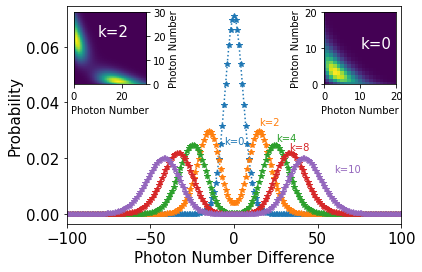

In [25]:
fig=plt.figure()
n_list=list(range(0,10,2))
for n_dect in n_list:
    psi_comb=psi_final_list[n_dect]
    (prob_arr,diff_arr,diff_probs)=QOtrunc.photon_number_diff_statistics(psi_comb)
    plt.plot(diff_arr,diff_probs,'*:')
plt.xlim([-100,100])
plt.text(-6,0.025,'k=0',color=colors[0])
plt.text(15,0.032,'k=2',color=colors[1])
plt.text(25,0.026,'k=4',color=colors[2])
plt.text(33,0.023,'k=8',color=colors[3])
plt.text(60,0.015,'k=10',color=colors[4])
ax0=plt.gca()
ax0.tick_params(labelsize=15)
plt.xlabel('Photon Number Difference',fontsize=15)
plt.ylabel('Probability',fontsize=15)
fig.add_axes([0.68,0.61,0.25,0.25])
psi_comb=psi_final_list[0]
(prob_arr,diff_arr,diff_probs)=QOtrunc.photon_number_diff_statistics(psi_comb)
plt.imshow(prob_arr,interpolation=None)
plt.xlim([0,20])
plt.ylim([0,20])
plt.text(10,10,'k=0',color='w',fontsize=15)
plt.xlabel('Photon Number',fontsize=10)
plt.ylabel('Photon Number',fontsize=10)
fig.add_axes([0.1,0.61,0.25,0.25])
psi_comb=psi_final_list[2]
(prob_arr,diff_arr,diff_probs)=QOtrunc.photon_number_diff_statistics(psi_comb)
plt.imshow(prob_arr,interpolation=None)
plt.xlim([0,30])
plt.ylim([0,30])
plt.text(10,20,'k=2',color='w',fontsize=15)
ax2=plt.gca()
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
plt.xlabel('Photon Number',fontsize=10)
plt.ylabel('Photon Number',fontsize=10)
#plt.savefig('figures/number_difference_even.pdf',bbox_inches='tight')
plt.show()

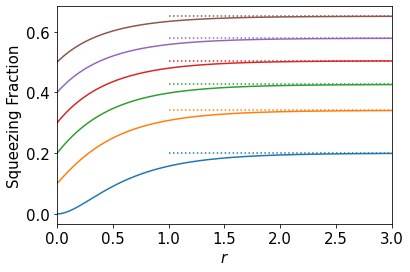

In [26]:
r_arr=np.linspace(0,3,200)
sq_frac_init_arr=np.linspace(0,0.5,6)
squeeze_fracs_r_fin=np.zeros([6,200])
squeeze_fracs_inf_r=np.zeros(6)
for i_sq_frac in range(len(sq_frac_init_arr)):
    squeeze_fracs_inf_r[i_sq_frac]=QOtrunc.calculate_fraction_from_squeezing_n_tot_frac(1,sq_frac_init_arr[i_sq_frac],np.inf)
    for i_r in range(len(r_arr)):
        squeeze_fracs_r_fin[i_sq_frac,i_r]=QOtrunc.calculate_fraction_from_squeezing_n_tot_frac(1,sq_frac_init_arr[i_sq_frac],r_arr[i_r])
    plt.plot(r_arr,squeeze_fracs_r_fin[i_sq_frac,:],color=colors[i_sq_frac])
    plt.plot([1,3],[squeeze_fracs_inf_r[i_sq_frac],squeeze_fracs_inf_r[i_sq_frac]],':',color=colors[i_sq_frac])
ax1=plt.gca()
ax1.tick_params(labelsize=15)
plt.xlabel(r'$r$',fontsize=15)
plt.ylabel('Squeezing Fraction',fontsize=15)
plt.xlim([0,3])
#plt.savefig('figures/sq_frac_r.pdf',bbox_inches='tight')
plt.show()

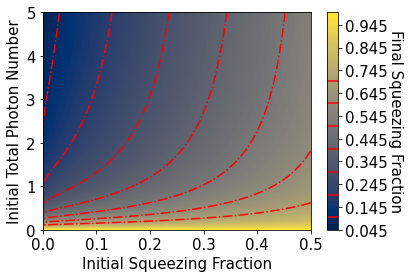

In [27]:
photon_num_init_arr=np.linspace(0,5,200)
sq_frac_init_arr=np.linspace(0,0.5,200)
squeeze_fracs_r_inf=np.zeros([200,200])
for i_photon_num_init in range(len(photon_num_init_arr)):
    for i_sq_frac in range(len(sq_frac_init_arr)):
        squeeze_fracs_r_inf[i_photon_num_init,i_sq_frac]=QOtrunc.calculate_fraction_from_squeezing_n_tot_frac(photon_num_init_arr[i_photon_num_init],sq_frac_init_arr[i_sq_frac],np.inf)
nrep=5 
for i in range(nrep): # slightly ugly hack to get rid of pdf artifacts
    plt.contourf(sq_frac_init_arr,photon_num_init_arr,squeeze_fracs_r_inf,levels=200,cmap=plt.cm.cividis)
cbar=plt.colorbar()
cbar.ax.get_yaxis().labelpad = 15
cbar.ax.set_ylabel('Final Squeezing Fraction',rotation=270,fontsize=15)
cbar.ax.tick_params(labelsize=15)
contours=plt.contour(sq_frac_init_arr,photon_num_init_arr,squeeze_fracs_r_inf,colors='red',levels=[0.1,0.2,0.3,0.4,0.5,0.6,0.7],linestyles='-.')
cbar.add_lines(contours)
ax1=plt.gca()
ax1.tick_params(labelsize=15)
plt.xlabel('Initial Squeezing Fraction',fontsize=15)
plt.ylabel('Initial Total Photon Number',fontsize=15)
plt.savefig('figures/sq_frac_inf_r_0_n.pdf',bbox_inches='tight')
plt.show()